## Importation des données

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px
import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


CLUSTER_COLORS = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#A8DADC']
BG         = '#0D1117'
FG         = '#E6EDF3'
GRID_COLOR = '#21262D'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': FG, 'xtick.color': FG, 'ytick.color': FG,
    'text.color': FG, 'grid.color': GRID_COLOR, 'grid.linewidth': 0.5,
    'font.family': 'monospace', 'figure.dpi': 130,
})

## Chargement des données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = "https://raw.githubusercontent.com/OpenExoplanetCatalogue/oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"

df = pd.read_csv(CSV_URL, comment='#', low_memory=False)

COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

df.columns = COLS[:len(df.columns)]

print(f"{len(df):,} planètes chargées")
print(f"\n Colonnes disponibles :\n{df.dtypes}")
print(f"\n Valeurs manquantes par colonne :")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# Nettoyage pour le clustering
cols_clustering = [
    'mass', 'radius', 'period', 'semi_major_axis',
    'eccentricity', 'host_star_mass', 'host_star_temp'
]

df_clean = df[cols_clustering].copy()
df_clean = df_clean.dropna(subset=['mass', 'radius'])
df_clean = df_clean[(df_clean['mass'] > 0) & (df_clean['radius'] > 0)]

print(f"\n Apres nettoyage : {len(df_clean):,} planètes avec masse et rayon positifs")
df_clean.head()

5,414 planètes chargées

 Colonnes disponibles :
name                      object
binary_flag                int64
mass                     float64
radius                   float64
period                   float64
semi_major_axis          float64
eccentricity             float64
periastron               float64
longitude                float64
ascending_node           float64
inclination              float64
surface_temp             float64
age                      float64
discovery_method          object
discovery_year           float64
last_updated              object
ra_string                 object
dec_string                object
distance_pc              float64
host_star_mass           float64
host_star_radius         float64
host_star_metallicity    float64
host_star_temp           float64
host_star_age            float64
list_flag                 object
dtype: object

 Valeurs manquantes par colonne :
age                      5410
longitude                5371
ascending_node   

,mass,radius,period,semi_major_axis,eccentricity,host_star_mass,host_star_temp
9,0.01189,0.152,0.669140,NaN,NaN,0.495,3434.0
15,2.24200,1.460,2.903675,0.04631,0.00,1.559,6050.0
19,0.00824,0.119,0.768448,0.01211,0.00,0.400,3331.0
20,0.02706,0.205,12.251900,0.07673,0.06,0.400,3331.0
21,0.50800,1.580,3.071722,0.03957,0.00,0.876,5017.0


## Acte II : Structures cachées

Dans l'Acte I, nous avons observé des tendances globales. Mais les exoplanètes forment-elles spontanément des familles ? Pour le savoir, nous allons utiliser un algorithme de clustering non supervisé : K-Means. Il va regrouper les planètes uniquement à partir de leurs propriétés physiques, sans regarder leur étiquette.

## Avant/ après nettoyage

Avant le clustering, nous nettoyons le jeu de données avec l'algorithme Local Outlier Factor (LOF). Il identifie les planètes aux propriétés anormales (peut-être des erreurs de mesure ou des cas trop extrêmes). Environ 5 % des données sont retirées pour ne pas fausser la suite.

In [23]:
LOF_FEATURES = [c for c in ['radius', 'mass', 'period', 'host_star_temp'] if c in df.columns]

print(f"\n Features pour LOF : {LOF_FEATURES}")

X_lof = np.log10(df[LOF_FEATURES].dropna().values)
idx_ok = df[LOF_FEATURES].dropna().index

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
mask = lof.fit_predict(X_lof) == 1

df = df.loc[idx_ok[mask]].copy()
print(f" LOF : {(~mask).sum()} outliers supprimés -> {len(df):,} planètes restantes")


 Features pour LOF : ['radius', 'mass', 'period', 'host_star_temp']
 LOF : 72 outliers supprimés -> 1,367 planètes restantes


### Préparation des features

In [24]:
FEATURE_COLS = [c for c in ['radius', 'mass', 'period', 'host_star_temp'] if c in df.columns]

df_feat = df.dropna(subset=FEATURE_COLS).copy()
X_log = np.log10(df_feat[FEATURE_COLS].values)
X = StandardScaler().fit_transform(X_log)

print(f"\n Features : {FEATURE_COLS}")
print(f" Matrice X : {X.shape}")


 Features : ['radius', 'mass', 'period', 'host_star_temp']
 Matrice X : (1367, 4)


### Choix du K optimal (Elbow + Silhouette)

Pour déterminer le nombre optimal de clusters, nous utilisons la méthode du coude (elbow method) qui examine la somme des distances internes aux clusters. Pour faire court, le coude sur la courbe indique le K où l’ajout d’un nouveau groupe n’apporte plus de gain significatif. On combine cette approche avec le coefficient de silhouette (silhouette score) qui mesure la cohésion interne et la séparation entre les clusters. La valeur maximale de ce coefficient signale la séparation la plus naturelle et interprétable des données.


 K optimal (max silhouette) = 3


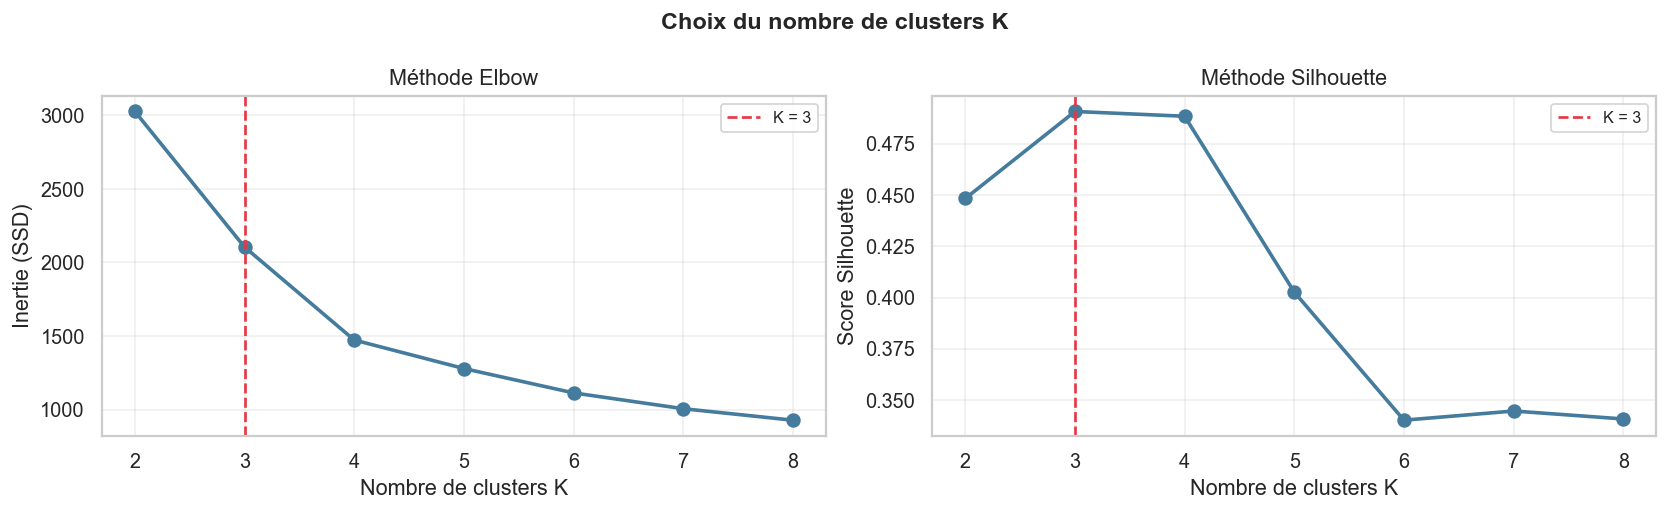

In [25]:
K_RANGE = range(2, 9)

inertias, silhouettes = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

BEST_K = list(K_RANGE)[np.argmax(silhouettes)]
print(f"\n K optimal (max silhouette) = {BEST_K}")

# visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choix du nombre de clusters K', fontsize=13, fontweight='bold')

for ax, vals, title, ylabel in [
    (axes[0], inertias, 'Méthode Elbow', 'Inertie (SSD)'),
    (axes[1], silhouettes, 'Méthode Silhouette', 'Score Silhouette'),
]:
    ax.plot(list(K_RANGE), vals, 'o-', color='#457B9D', lw=2, ms=7)
    ax.axvline(BEST_K, color='#E63946', ls='--', lw=1.5, label=f'K = {BEST_K}')
    ax.set_xlabel('Nombre de clusters K')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

L'inertie chute visiblement en passant de 3 à 4 clusters. De plus, la qualité du cluster est optimal pour 3 clusters. Il est donc logique de prendre K=3.

### K-Means et visualisation des clusters

In [27]:
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_feat = df_feat.copy()
df_feat['cluster'] = km.fit_predict(X)

# Trie les clusters par rayon médian
order = df_feat.groupby('cluster')['radius'].median().sort_values().index
mapping = {old: new for new, old in enumerate(order)}
df_feat['cluster'] = df_feat['cluster'].map(mapping)

COLORS = [CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i in range(BEST_K)]

# Noms des clusters
CLUSTER_NAMES = {
    0: 'Rocheuses',
    1: 'Super-Terres',
    2: 'Neptunes chaudes',
}
patches = [mpatches.Patch(color=COLORS[i],
           label=f'C{i} – {CLUSTER_NAMES.get(i, f"Groupe {i}")}') for i in range(BEST_K)]

fig = plt.figure(figsize=(15, 5.5))
fig.suptitle('Structures cachées révélées par K-Means', fontsize=14, fontweight='bold')
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

<Figure size 1950x715 with 0 Axes>

## Clusters dans l'espace Masse-Rayon

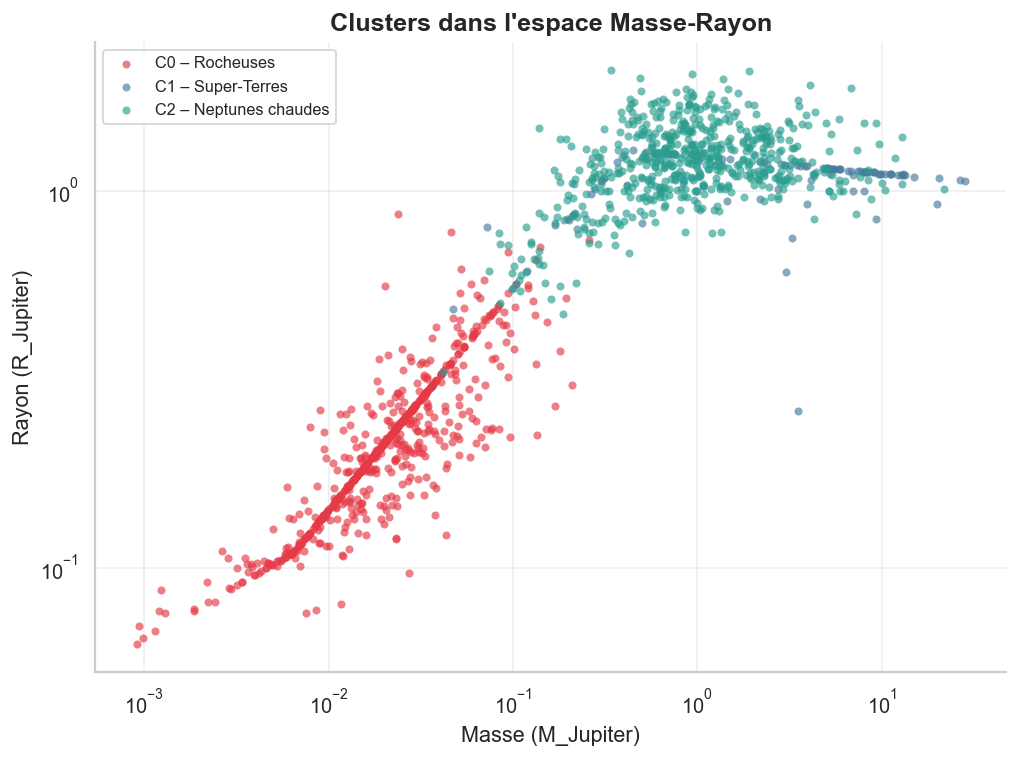

In [28]:
plt.figure(figsize=(8, 6))

for i in range(BEST_K):
    sub = df_feat[df_feat['cluster'] == i]
    plt.scatter(sub['mass'], sub['radius'],
                s=20, alpha=0.65, color=COLORS[i], linewidths=0, label=f'C{i} – {CLUSTER_NAMES.get(i, f"Groupe {i}")}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masse (M_Jupiter)', fontsize=12)
plt.ylabel('Rayon (R_Jupiter)', fontsize=12)
plt.title('Clusters dans l\'espace Masse-Rayon', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)

# Enlever les cadres du haut et droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Le clustering révèle trois groupes distincts. Les planètes du Système Solaire se placent naturellement. La séparation est nette et confirme que ces familles correspondent à des réalités physiques.

## Projection PCA des clusters

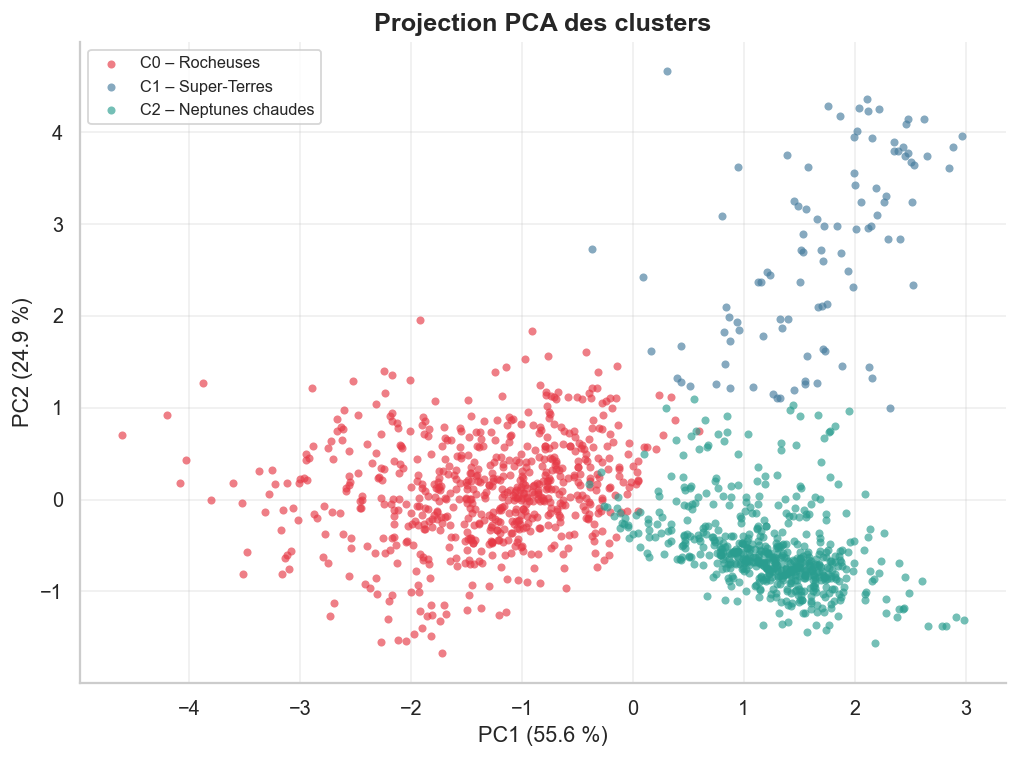

In [29]:
from sklearn.decomposition import PCA

# Calcul de la PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
ev = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

for i in range(BEST_K):
    mask = df_feat['cluster'].values == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=20, alpha=0.65, color=COLORS[i], linewidths=0, label=f'C{i} – {CLUSTER_NAMES.get(i, f"Groupe {i}")}')

plt.xlabel(f'PC1 ({ev[0]*100:.1f} %)', fontsize=12)
plt.ylabel(f'PC2 ({ev[1]*100:.1f} %)', fontsize=12)
plt.title('Projection PCA des clusters', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)

# Enlever les cadres du haut et droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Pour vérifier la robustesse des groupes, nous projetons les données dans un espace à deux dimensions (PCA). Les clusters restent bien séparés, même après réduction de dimension. Cela confirme que nos groupes sont cohérents et ne dépendent pas d'une seule variable.

In [10]:
# Regarde les quartiles pour chaque cluster
summary_detailed = df_feat.groupby('cluster')[['radius', 'mass', 'period']].describe()
print(summary_detailed)

        radius                                                             \
         count      mean       std    min      25%    50%      75%    max   
cluster                                                                     
0        671.0  0.228465  0.116648  0.063  0.14700  0.207  0.26796  1.070   
1        100.0  1.058399  0.183503  0.260  1.01000  1.119  1.15250  1.280   
2        596.0  1.208039  0.280654  0.331  1.03175  1.190  1.38650  2.085   

          mass            ...                     period               \
         count      mean  ...       75%       max  count         mean   
cluster                   ...                                           
0        671.0  0.028431  ...  0.033015   0.30425  671.0    16.232291   
1        100.0  5.286372  ...  8.016662  28.26000  100.0  6526.881028   
2        596.0  1.482902  ...  1.771250  21.66000  596.0     6.724077   

                                                                       \
                 std     

Pour confirmer l'identification de nos clusters, penchons-nous sur leur composition interne. Le clustering a séparé naturellement les exoplanètes en trois groupes :

- Les Rocheuses (C0): petites, denses, proches de leur étoile (elles sont composées de roche et de fer.

- Les Super-Terres froides (C1) : massives, de taille intermédiaire, sur des orbites très lointaines (possiblement des mini-Neptunes ou géantes de glace)

- Les Neptunes chaudes (C2) : taille Neptune, masse élevée, périodes ultra-courtes, atmosphère gonflée par la chaleur.

La cohérence entre les propriétés physiques (masse, rayon, période, densité) et les classes connues en astronomie valide notre clustering.

## Apparition d'un biais de détection

 Méthodes analysées : ['transit', 'RV', 'imaging', 'timing']


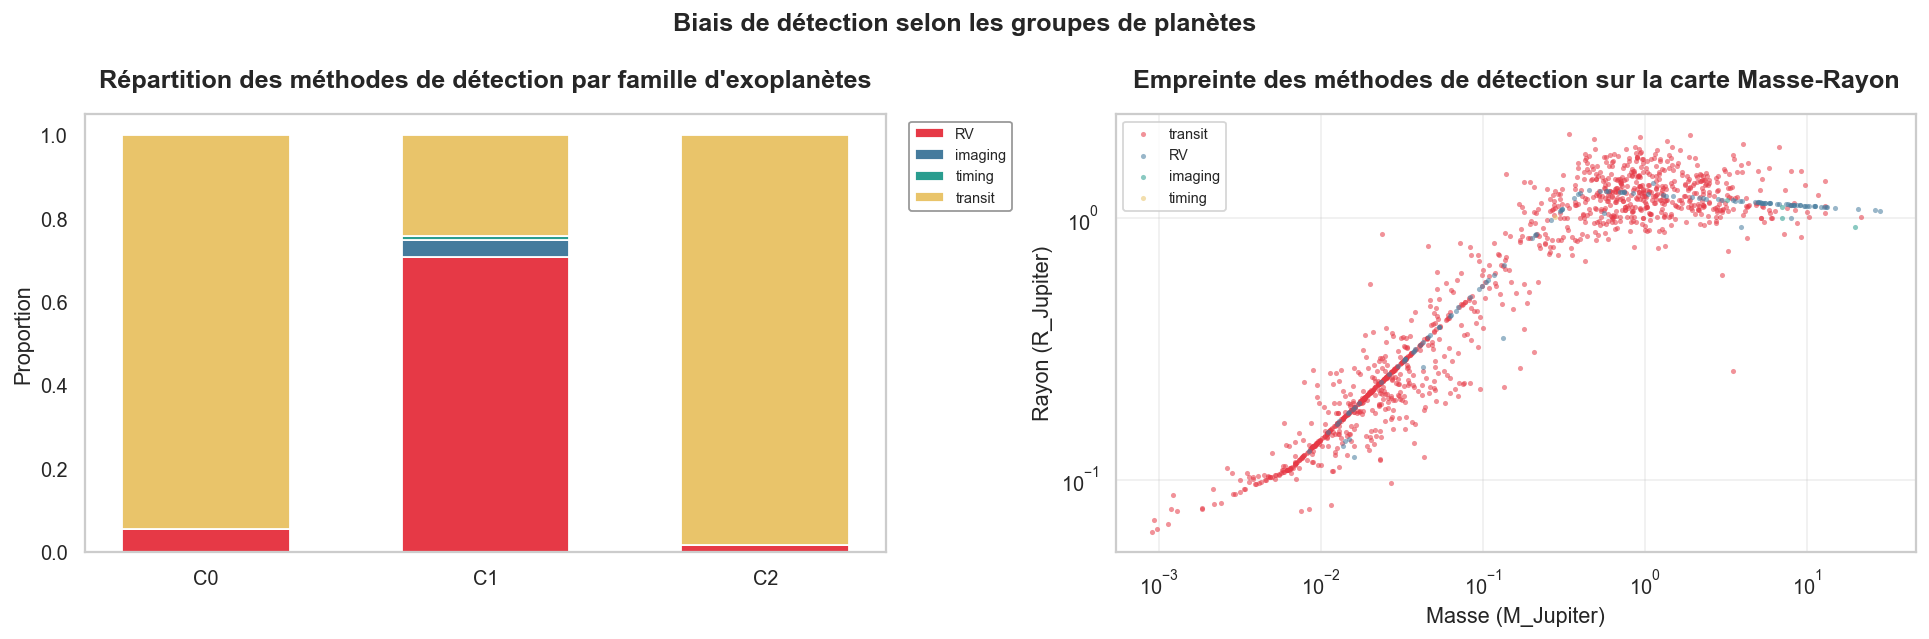

In [20]:
if 'discovery_method' not in df_feat.columns:
    print(' Colonne discovery_method absente. Vérifie le nom exact.')
    print(f"Colonnes disponibles : {df_feat.columns.tolist()}")
else:
    # récupère les 4 méthodes les plus fréquentes
    top_methods = df_feat['discovery_method'].value_counts().head(4).index.tolist()
    METHOD_COLORS = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
    method_palette = {m: METHOD_COLORS[i] for i, m in enumerate(top_methods)}

    print(f" Méthodes analysées : {top_methods}")

    # Filtre et crée le tableau croisé
    sub = df_feat[df_feat['discovery_method'].isin(top_methods)]
    ct = pd.crosstab(sub['cluster'], sub['discovery_method'], normalize='index')

    # Création de la figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Biais de détection selon les groupes de planètes',
                 fontsize=14, fontweight='bold')

    # Barres empilées
    ax = axes[0]
    bottom = np.zeros(BEST_K)
    for j, meth in enumerate(ct.columns):
        vals = ct[meth].reindex(range(BEST_K), fill_value=0).values
        ax.bar(range(BEST_K), vals, bottom=bottom,
               color=METHOD_COLORS[j % len(METHOD_COLORS)], label=meth, width=0.6)
        bottom += vals
    ax.set_xticks(range(BEST_K))
    ax.set_xticklabels([f'C{i}' for i in range(BEST_K)])
    ax.set_ylabel('Proportion')
    ax.set_title('Répartition des méthodes de détection par famille d\'exoplanètes', fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, facecolor='white', edgecolor='gray')
    ax.grid(False)

    #  Nuage masse/rayon par méthode
    ax2 = axes[1]
    for meth in top_methods:
        s = df_feat[df_feat['discovery_method'] == meth]
        ax2.scatter(s['mass'], s['radius'],
                    s=8, alpha=0.55, color=method_palette[meth],
                    linewidths=0, label=meth)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Masse (M_Jupiter)')
    ax2.set_ylabel('Rayon (R_Jupiter)')
    ax2.set_title('Empreinte des méthodes de détection sur la carte Masse-Rayon', fontsize=14, fontweight='bold', pad=15)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Le clustering a révélé trois familles d'exoplanètes aux propriétés bien distinctes. Mais en regardant les méthodes de détection associées à chaque cluster, un biais apparaît. Les clusters C0 (rocheuses) et C2 (Neptunes chaudes) sont quasi exclusivement détectés par transit, tandis que le cluster C1 (super-Terres froides) l'est majoritairement par vitesse radiale.

Ce n'est pas un hasard. Ces deux méthodes ne sondent pas les mêmes populations : le transit excelle pour les planètes petites ou proches de leur étoile, la vitesse radiale pour les planètes massives.

Nous nous pencherons davantage sur le biais observationnel dans l'Acte III

## Architecture d'un système

Parmi les milliers de systèmes exoplanétaires référencés, TRAPPIST-1 se distingue par la complétude de ses informations. Il appartient à la première famille (C0). Masse, rayon, période et distance sont connus pour chacune de ses sept planètes. Cela nous permet d'obtenir une visualisation fidèle de son architecture.

In [28]:
# Vérifie les données disponibles pour TRAPPIST-1
df_trappist = df[df['name'].str.contains("TRAPPIST-1", case=False, na=False)].copy()

print("\nDonnées par planète :")
for _, row in df_trappist.iterrows():
    print(f"\n {row['name']}")
    print(f"   Masse (MJ) : {row['mass'] if pd.notna(row['mass']) else 'Non renseignée'}")
    print(f"   Rayon (RJ) : {row['radius'] if pd.notna(row['radius']) else 'Non renseigné'}")
    print(f"   Période (jours) : {row['period'] if pd.notna(row['period']) else 'Non renseignée'}")
    print(f"   Demi-grand axe (UA) : {row['semi_major_axis'] if pd.notna(row['semi_major_axis']) else 'Non renseigné'}")
    print(f"   Excentricité : {row['eccentricity'] if pd.notna(row['eccentricity']) else 'Non renseignée'}")


Données par planète :

 TRAPPIST-1 b
   Masse (MJ) : 0.0032
   Rayon (RJ) : 0.10001
   Période (jours) : 1.5108739
   Demi-grand axe (UA) : 0.01154775
   Excentricité : 0.00622

 TRAPPIST-1 c
   Masse (MJ) : 0.003637
   Rayon (RJ) : 0.09769
   Période (jours) : 2.421818
   Demi-grand axe (UA) : 0.01581512
   Excentricité : 0.00654

 TRAPPIST-1 d
   Masse (MJ) : 0.000934
   Rayon (RJ) : 0.06994
   Période (jours) : 4.04982
   Demi-grand axe (UA) : 0.02228038
   Excentricité : 0.00837

 TRAPPIST-1 e
   Masse (MJ) : 0.002429
   Rayon (RJ) : 0.08118
   Période (jours) : 6.09957
   Demi-grand axe (UA) : 0.02928285
   Excentricité : 0.0051

 TRAPPIST-1 f
   Masse (MJ) : 0.002939
   Rayon (RJ) : 0.09332
   Période (jours) : 9.20648
   Demi-grand axe (UA) : 0.03853361
   Excentricité : 0.01007

 TRAPPIST-1 g
   Masse (MJ) : 0.003612
   Rayon (RJ) : 0.10242
   Période (jours) : 12.35281
   Demi-grand axe (UA) : 0.04687692
   Excentricité : 0.00208

 TRAPPIST-1 h
   Masse (MJ) : 0.001041
   Ray

 TRAPPIST-1 : 7 planètes
    TRAPPIST-1 b : 0.0032 MJ
    TRAPPIST-1 c : 0.0036 MJ
    TRAPPIST-1 d : 0.0009 MJ
    TRAPPIST-1 e : 0.0024 MJ
    TRAPPIST-1 f : 0.0029 MJ
    TRAPPIST-1 g : 0.0036 MJ
    TRAPPIST-1 h : 0.0010 MJ


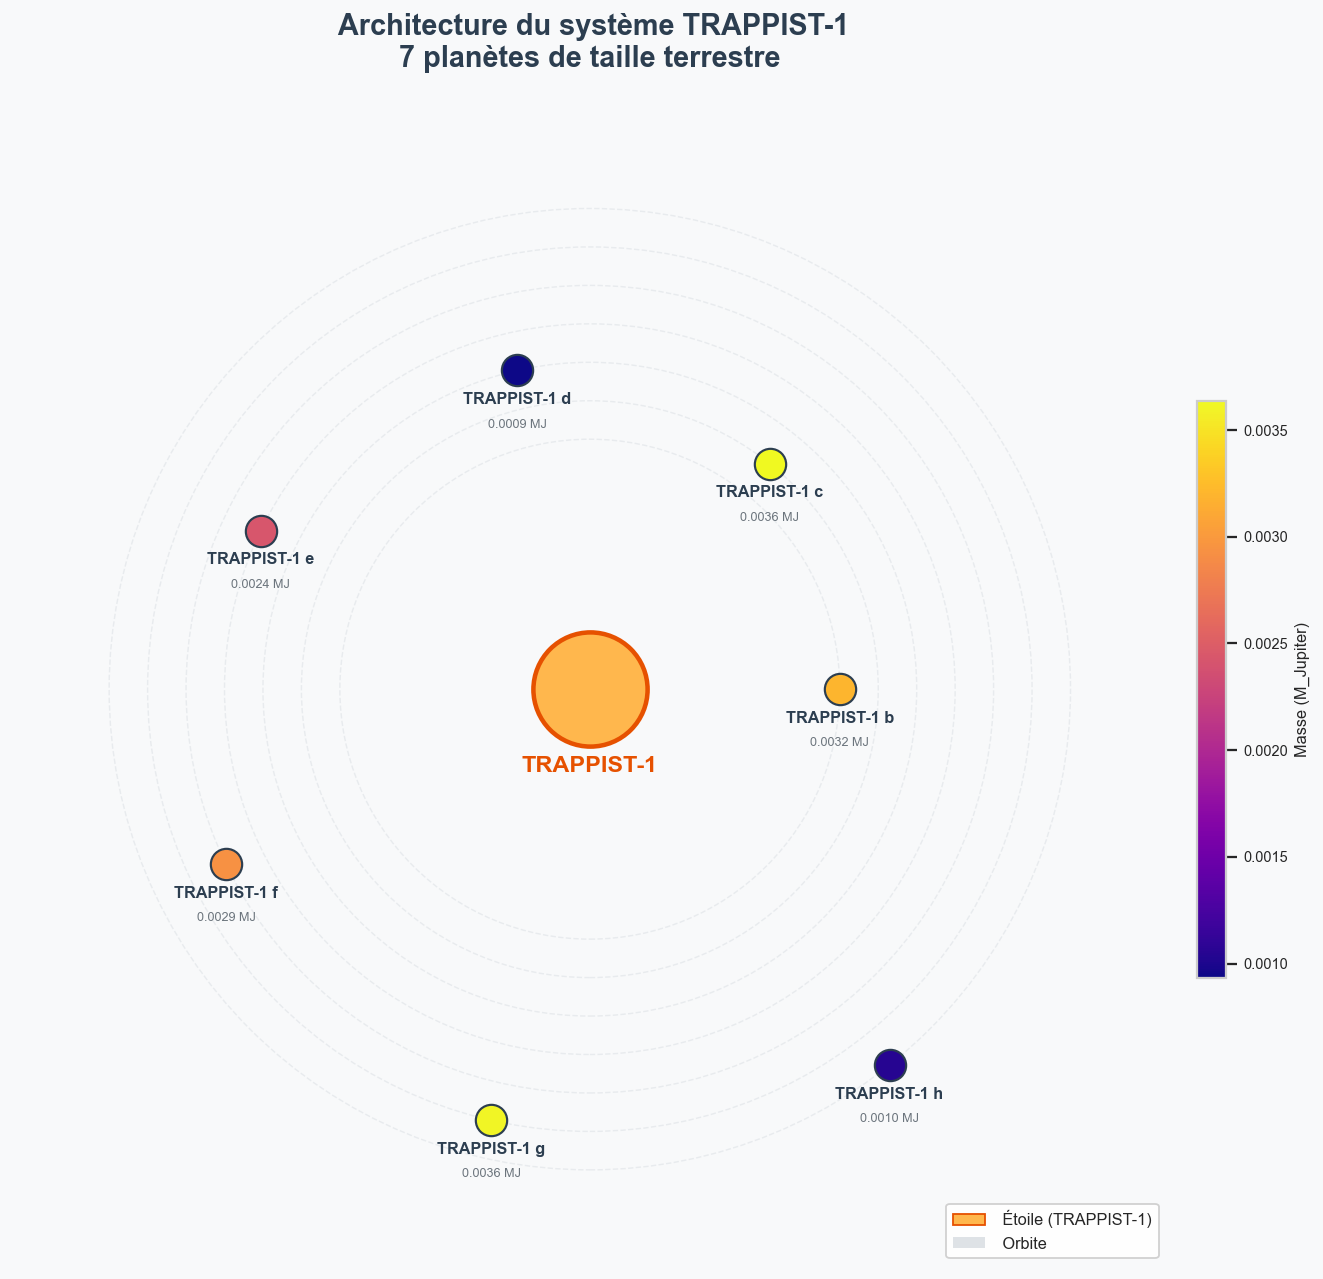

In [26]:
def plot_trappist(df):
    system_name = "TRAPPIST-1"
    df_system = df[df['name'].str.contains(system_name, case=False, na=False)].copy()

    if len(df_system) == 0:
        print(f"Système '{system_name}' non trouvé.")
        return

    # Tri par période orbitale
    if 'period' in df_system.columns:
        df_system = df_system.sort_values('period')

    planets = df_system['name'].tolist()
    n = len(planets)
    masses = [float(row['mass']) for _, row in df_system.iterrows()]

    print(f" {system_name} : {n} planètes")
    for name, mass in zip(planets, masses):
        print(f"    {name} : {mass:.4f} MJ")

    # Layout circulaire
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radii = np.linspace(1.3, 2.5, n)

    # Figure
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    # Étoile au centre
    ax.scatter(0, 0, s=4000, color='#FFB74D', edgecolors='#E65100', linewidth=2.5, zorder=5)
    ax.text(0, -0.4, system_name, ha='center', va='center', fontsize=13, fontweight='bold', color='#E65100')

    # Cercles d'orbite et planètes
    norm = Normalize(vmin=min(masses), vmax=max(masses))
    cmap = plt.cm.plasma

    for i, (_, row) in enumerate(df_system.iterrows()):
        name = row['name']
        mass = float(row['mass'])
        r = radii[i]
        angle = angles[i]
        x = r * np.cos(angle)
        y = r * np.sin(angle)

        # Taille proportionnelle à la masse
        size = 300 + np.log1p(mass) * 400

        # Cercle d'orbite
        orbit = plt.Circle((0, 0), r, color='#DEE2E6', linewidth=0.8, linestyle='--', fill=False, alpha=0.6)
        ax.add_patch(orbit)

        # Planète
        ax.scatter(x, y, s=size, color=cmap(norm(mass)), edgecolors='#2C3E50', linewidth=1.2, zorder=10)

        # Label
        ax.text(x, y - 0.15, name, ha='center', va='center', fontsize=9, fontweight='bold', color='#2C3E50')
        ax.text(x, y - 0.28, f'{mass:.4f} MJ', ha='center', va='center', fontsize=7, color='#6C757D')

    # Réglages
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axis('off')

    # Titre
    ax.set_title(f" Architecture du système TRAPPIST-1\n7 planètes de taille terrestre",
                 fontsize=16, fontweight='bold', color='#2C3E50', pad=25)

    # Barre de couleur
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label('Masse (M_Jupiter)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    legend_elements = [
        mpatches.Patch(facecolor='#FFB74D', edgecolor='#E65100', label=' Étoile (TRAPPIST-1)'),
        mpatches.Patch(facecolor='#DEE2E6', edgecolor='none', label=' Orbite'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

plot_trappist(df)

Ce que montre la visualisation

- Au centre : l'étoile TRAPPIST-1 (naine rouge)
- Autour : sept planètes de taille terrestre sur des orbites concentriques
- Taille des planètes : proportionnelle à leur masse
- Couleurs : distinguent visuellement les sept planètes
- Tri par période : disposées par ordre de période orbitale

Le système est très compact. Toutes les orbites tiendraient à l'intérieur de celle de Mercure.

TRAPPIST-1 illustre la diversité des architectures exoplanétaires. Loin de notre système solaire, des systèmes de planètes rocheuses peuvent exister et certaines pourraient même abriter des conditions favorables à la vie.